In [21]:
import shap
import joblib
import pandas as pd
import json
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from sklearn.model_selection import train_test_split

In [4]:
model = joblib.load("../models/model_v1_auc_0.95757.joblib")

In [11]:
with open('../feature_selection/magic_25_features.json' , 'r') as f:
    features = json.load(f)

lazy_df = pl.scan_parquet('../dataset/final_train_data/final_data.parquet')

num_cols = [c for c in features if "_mean" in c or "_last" in c or "_delta" in c]
lazy_df = lazy_df.with_columns([
    (pl.col(c) * 100).floor() / 100 for c in num_cols
])

cols_to_load = features + ["target"]
final_df = lazy_df.select(cols_to_load).collect()

X = final_df.select(features).to_pandas()
y = final_df["target"].to_pandas()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_test)

X_summary = shap.kmeans(X_scaled,1000).data



 99%|===================| 991/1000 [01:23<00:00]        

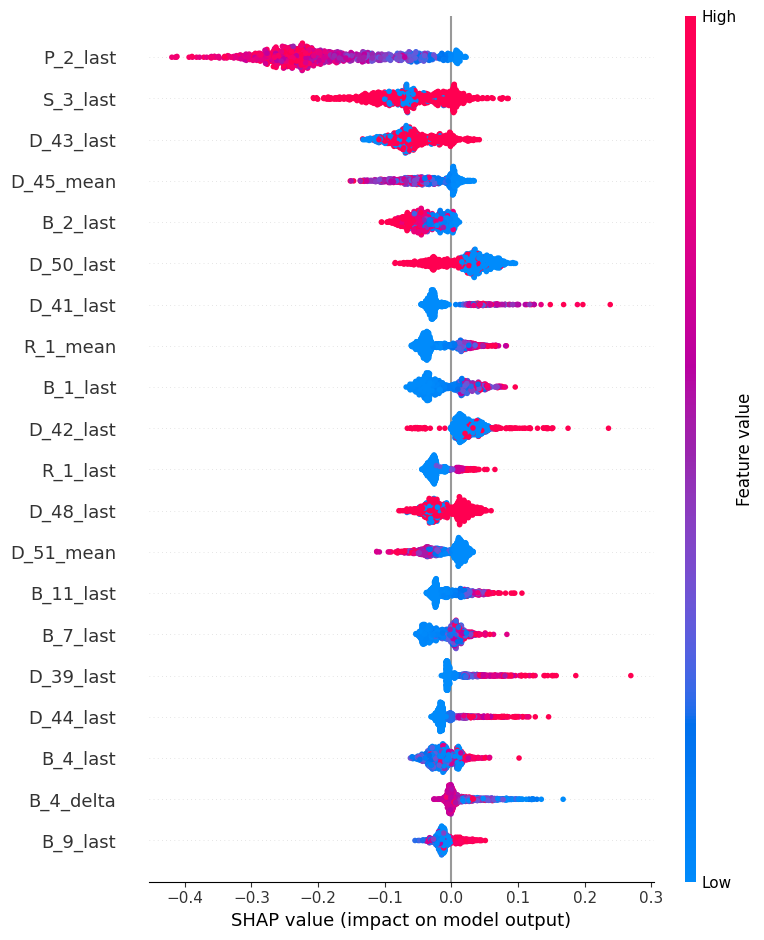

In [19]:
X_explain = X_test.sample(n = 1000,random_state = 42)

explainer = shap.TreeExplainer(
    model,
    data = X_summary,
    feature_perturbation="interventional",
    model_output = "probability"
)

shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values,X_explain)


This SHAP Beeswarm plot validates the Global Interpretability of our LightGBM model. By analyzing 1,000 representative samples, we confirmed that the model has internalized key financial heuristics.Red represents a high value for that feature; blue represents a low value. Points to the right of the center line (0.0) increase the probability of default. Points to the left decrease it.. Specifically, our primary feature, $P\_2\_last$, shows a strong negative correlation with risk, where high payment values (red) drastically push the prediction toward the 'Safe' zone. Conversely, delinquency trends captured in features like $B\_4\_delta$ allow the model to detect escalating risk before a default actually occurs. This visualization bridges the gap between our 0.95 AUC and a transparent, bank-ready decision system.

The 3 most 'confusing' customers for the model:

Case 1: Predicted Risk = 0.5014


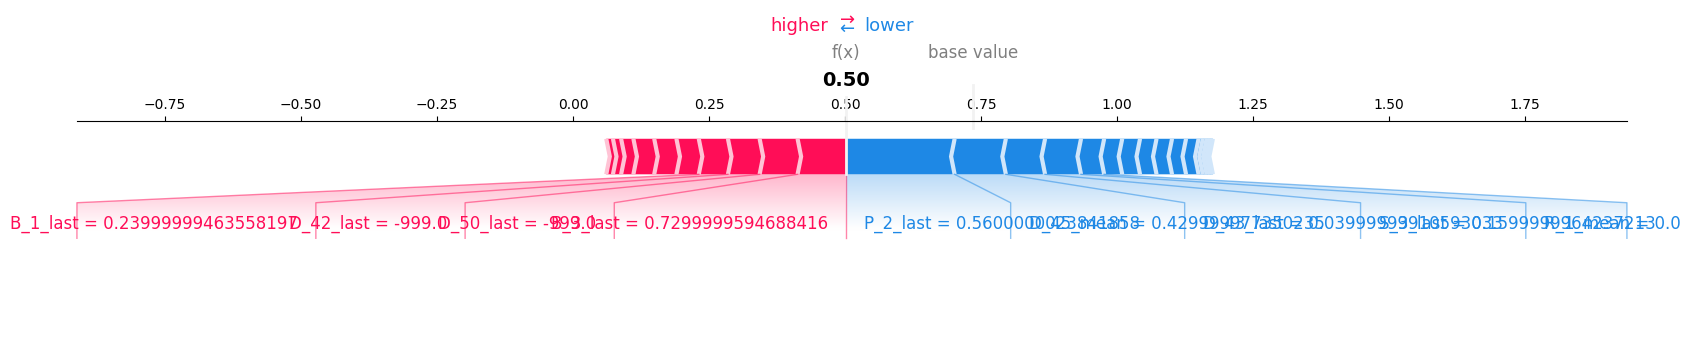


Case 2: Predicted Risk = 0.4968


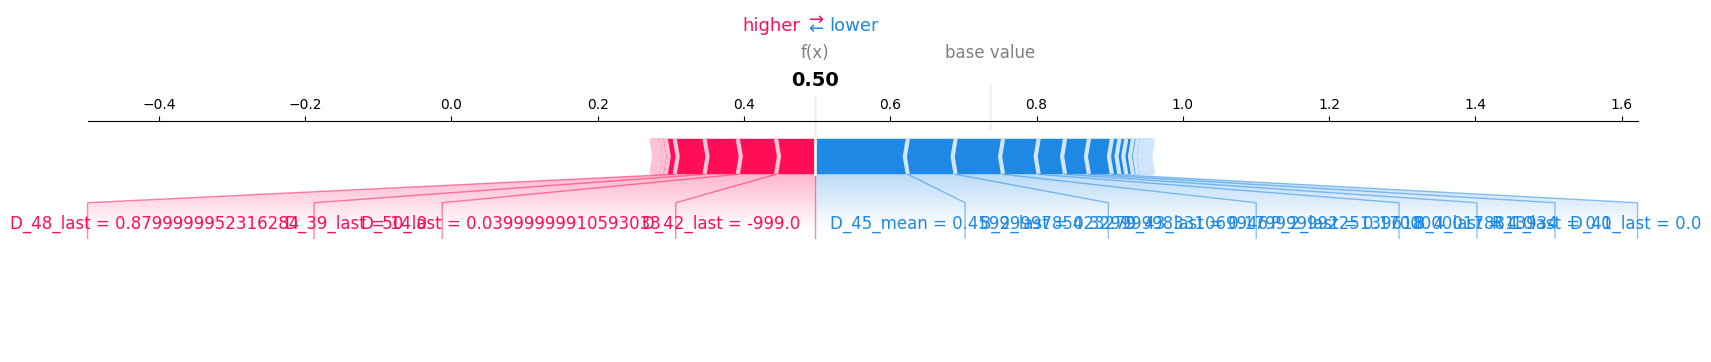


Case 3: Predicted Risk = 0.4964


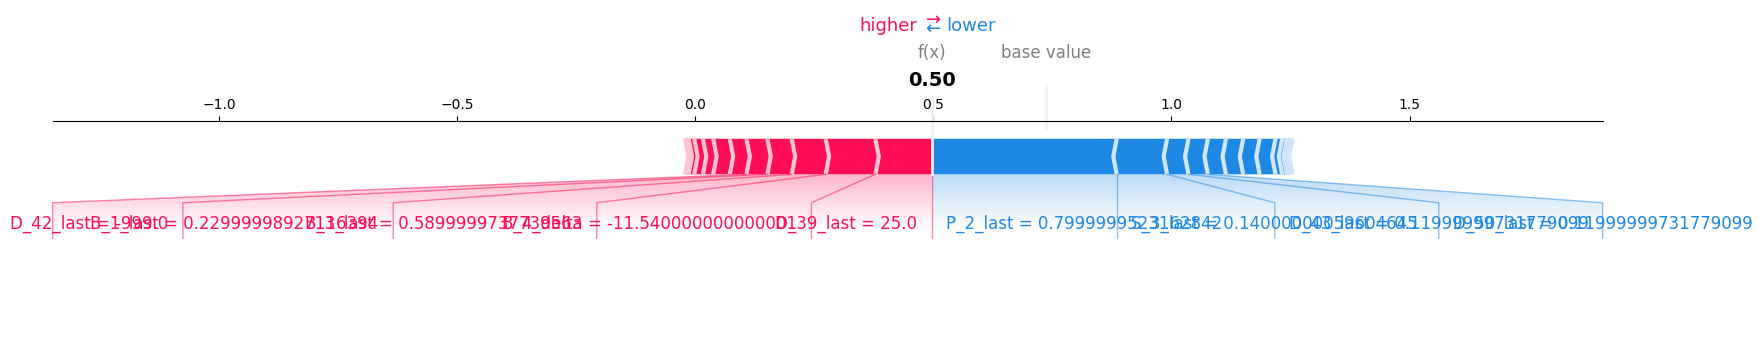

In [24]:
probs = model.predict_proba(X_explain)[:, 1]  # ✅ use X_explain

uncertainty = np.abs(probs - 0.5)
confusing_indices = np.argsort(uncertainty)[:3]

print("The 3 most 'confusing' customers for the model:")

for i, idx in enumerate(confusing_indices):
    print(f"\nCase {i+1}: Predicted Risk = {probs[idx]:.4f}")
    
    shap_viz = shap.force_plot(
        explainer.expected_value,   
        shap_values[idx, :],       
        X_explain.iloc[idx, :],    
        matplotlib=True
    )
    plt.show()